In [210]:
from RRAM import Plot_PostProcess as pplt
from RRAM import Constants as cte

import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [211]:
I0 = cte.I_0
potencial = cte.pb_metal_insul
permitividad = cte.permitividad_relativa
init_temp = 300
num_simulation = 0

In [212]:
# Represento los datos de la simulación
# pplt.Plot_paneles(f'Results/resultados_{num_simulation}.csv',
#                   col_indices_x=[1],
#                   col_indices_y=[3],
#                   save_path=f'Results/resultados_presentaicon_{num_simulation}',
#                   global_tittle=fr'$\phi_{{B}}$ = {potencial} eV, $\varepsilon_r$ = {permitividad}, $I_0$ = {I0:.1e} A, $T_0$ = {init_temp} K',
#                   log_scale=[None])

# pplt.Plot_paneles(f'Results/resultados_{num_simulation}.csv',
#                   col_indices_x=[0],
#                   col_indices_y=[7],
#                   save_path=f'Results/Campo_gap_{num_simulation}',
#                   log_scale=[None])

In [213]:
def config_ax(ax):
    ax.grid(which='major', color='#DDDDDD', linewidth=0.8, zorder=-1)
    # Show the minor grid as well. Style it in very light gray as a thin,
    # dotted line.
    ax.grid(which='minor', color='#DEDEDE', linestyle=':', linewidth=0.5, zorder=-1)
    # Make the minor ticks and gridlines show.
    ax.minorticks_on()

    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)


def setup_plt(plt, latex=True, scaling=1):

    plt.rcParams.update(
        {
            "pgf.texsystem": "pdflatex",
            "text.usetex": latex,
            "font.family": "fourier",
            "text.latex.preamble": "\n".join([  # plots will use this preamble
                r"\usepackage[utf8]{inputenc}",
                r"\usepackage[T1]{fontenc}",
                r"\usepackage{siunitx}",
            ])
        }
    )

    SMALL_SIZE = 8 * scaling
    MEDIUM_SIZE = 10 * scaling
    BIGGER_SIZE = 12 * scaling

    plt.rc('font', size=SMALL_SIZE)             # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)        # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)       # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)       # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)       # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)       # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)     # fontsize of the figure title

In [214]:
setup_plt(plt, latex=True, scaling=1.5)

data_path = 'Results/resultados_0.csv'

 Tiempo simulación [s]
 Campo Simple [V/m]
 Campo Gap medio [V/m]


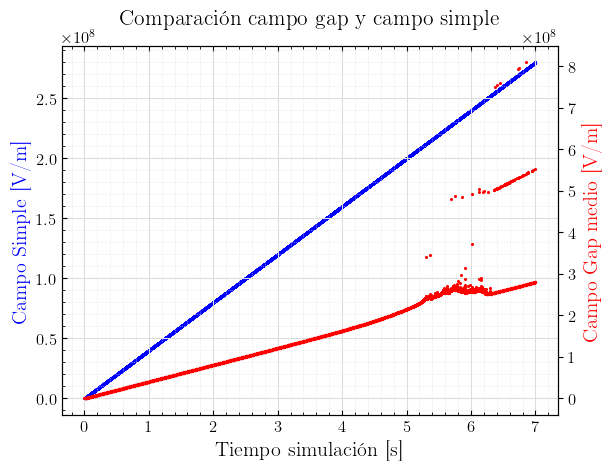

In [215]:
# leo los datos desde el csv
data = pd.read_csv(data_path)

col_indices_x = 0
col_indices_y = [6, 7]

# Extraigo la variable independiente
x1 = data.iloc[:, col_indices_x]

# Extraigo las variables dependientes
y1 = data.iloc[:, col_indices_y[0]]

# Extraigo la variable independiente
x2 = data.iloc[:, col_indices_x]

# Extraigo las variables dependientes
y2 = data.iloc[:, col_indices_y[1]]

print(data.columns[col_indices_x])
print(data.columns[col_indices_y[0]])
print(data.columns[col_indices_y[1]])

fig, axes = plt.subplots()
config_ax(axes)

axes.set_xlabel(data.columns[col_indices_x])
axes.set_ylabel(data.columns[col_indices_y[0]], color='blue')

axes.set_title('Comparación campo gap y campo simple', fontsize=16, pad=15)

axes.scatter(x1, y1, label='Campo gap', s=1.5, color='blue')

twin_axes = axes.twinx()
twin_axes.scatter(x2, y2, label='Campo simple', s=1.5, color='r')
twin_axes.set_ylabel(data.columns[col_indices_y[1]], color='r')

plt.show()
save_path = 'Results/campo_gap_vs_campo_simple'
fig.savefig(save_path + '.pdf', bbox_inches='tight')

 Voltaje [V]
 Campo Simple [V/m]
 Campo Gap medio [V/m]


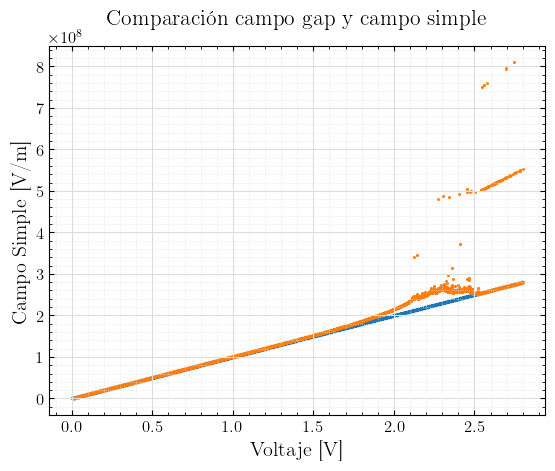

In [216]:
# leo los datos desde el csv
data = pd.read_csv(data_path)

col_indices_x = 1
col_indices_y = [6, 7]

# Extraigo la variable independiente
x1 = data.iloc[:, col_indices_x]

# Extraigo las variables dependientes
y1 = data.iloc[:, col_indices_y[0]]

# Extraigo la variable independiente
x2 = data.iloc[:, col_indices_x]

# Extraigo las variables dependientes
y2 = data.iloc[:, col_indices_y[1]]

print(data.columns[col_indices_x])
print(data.columns[col_indices_y[0]])
print(data.columns[col_indices_y[1]])

fig, axes = plt.subplots()
config_ax(axes)

axes.set_xlabel(data.columns[col_indices_x])
axes.set_ylabel(data.columns[col_indices_y[0]])

axes.set_title('Comparación campo gap y campo simple', fontsize=16, pad=15)

axes.scatter(x1, y1, label='Campo gap', s=1.5)
axes.scatter(x2, y2, label='Campo gap', s=1.5)

plt.show()
save_path = 'Results/campo_gap_vs_campo_simple'
fig.savefig(save_path + '.pdf', bbox_inches='tight')